# 03 - Implied Volatility and Smile Analysis

Computes implied volatility for each cleaned option quote, fits a smoothed smile
per expiry using SVI (Stochastic Volatility Inspired) parametrisation, builds a
2D volatility surface by interpolating in total implied variance space, and
produces the engine IV used by all downstream pricing notebooks.

**Inputs**
- `data/processed/options_clean.csv`
- `data/raw/spot_history.csv`

**Outputs**
- `data/processed/options_with_iv.csv`
- `data/processed/options_with_iv_engine.csv`
- `data/processed/smile_logmoneyness.csv`
- `data/processed/smile_svi.csv`
- `data/processed/svi_params.csv`
- `data/processed/vol_surface_points.csv`
- `data/processed/iv_surface_linear.pkl`
- `data/processed/iv_surface_nearest.pkl`
- `data/processed/iv_vs_realized_summary.csv`
- `outputs/plots/` - smile and surface plots
- `outputs/tables/` - IV and SVI summary tables

**Notebook flow**
1. Imports and configuration
2. Load cleaned option dataset
3. Black-Scholes pricing functions
4. Implied volatility solver
5. Compute implied volatility
6. IV diagnostics
7. Filter invalid IV values
8. IV solver validation
9. OTM-only representative smile
10. SVI smile fitting
11. Realized volatility benchmark
12. Near-ATM IV vs realized vol
13. Build volatility surface in total variance space
14. No-arbitrage term structure check
15. Engine IV for pricing models
16. Surface visualisation
17. Save all outputs
18. Final summary

## 1. Imports and configuration

In [374]:
# Standard library
import tomllib
from pathlib import Path

# Numerical and data libraries
import numpy as np
import pandas as pd

# Serialisation: used to persist surface interpolators for NB04
import joblib

# Plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Statistics / optimisation
from scipy.stats import norm
from scipy.optimize import brentq, minimize
from scipy.interpolate import (
    LinearNDInterpolator,
    NearestNDInterpolator,
    griddata,
)

plt.rcParams["figure.figsize"]  = (10, 6)
plt.rcParams["axes.grid"]       = True
plt.rcParams["axes.titlesize"]  = 13
plt.rcParams["axes.labelsize"]  = 11
plt.rcParams["legend.fontsize"] = 9

Path("outputs/plots").mkdir(parents=True, exist_ok=True)
Path("outputs/tables").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

In [375]:
# Load project configuration.
# risk_free_rate and dividend_yield flow into every BS and IV calculation
# in this notebook, so both must be loaded explicitly here.

with open("config.toml", "rb") as f:
    config = tomllib.load(f)

ticker         = config["ticker"]
risk_free_rate = config["risk_free_rate"]
dividend_yield = config["dividend_yield"]  # q = 0.0 for GOOG (no dividend)

print("Ticker         :", ticker)
print("Risk-free rate :", risk_free_rate)
print("Dividend yield :", dividend_yield)

Ticker         : GOOG
Risk-free rate : 0.045
Dividend yield : 0.0


## 2. Load cleaned option dataset

In [376]:
options_clean = pd.read_csv("data/processed/options_clean.csv")

options_clean["valuation_date"] = pd.to_datetime(options_clean["valuation_date"])
options_clean["expiration"]     = pd.to_datetime(options_clean["expiration"])

numeric_cols = [
    "strike", "bid", "ask", "mid", "lastprice", "volume",
    "impliedvolatility", "days_to_expiry", "ttm", "spot",
    "moneyness", "log_moneyness"
]
for col in numeric_cols:
    if col in options_clean.columns:
        options_clean[col] = pd.to_numeric(options_clean[col], errors="coerce")

print("Clean dataset shape:", options_clean.shape)
options_clean.head()

Clean dataset shape: (193, 28)


,contractsymbol,lasttradedate,strike,lastprice,bid,ask,change,percentchange,volume,openinterest,...,mid,days_to_expiry,ttm,spot,moneyness,spread,spread_over_mid,trade_age_days,log_moneyness,maturity_bucket
0,GOOG260327C00260000,2026-03-12 19:35:13,260.0,45.48,46.40,48.35,0.000000,0.000000,5.0,25,...,47.375,10,0.027397,304.420013,0.854083,1.95,0.041161,5,-0.157727,weekly
1,GOOG260327C00265000,2026-03-16 19:01:15,265.0,39.66,41.50,43.30,0.000000,0.000000,2.0,19,...,42.400,10,0.027397,304.420013,0.870508,1.80,0.042453,1,-0.138679,weekly
2,GOOG260327C00270000,2026-03-16 19:18:15,270.0,34.62,36.55,38.40,0.000000,0.000000,16.0,14,...,37.475,10,0.027397,304.420013,0.886932,1.85,0.049366,1,-0.119986,weekly
3,GOOG260327C00275000,2026-03-17 15:46:14,275.0,31.52,31.70,33.55,2.370001,8.130363,6.0,22,...,32.625,10,0.027397,304.420013,0.903357,1.85,0.056705,0,-0.101637,weekly
4,GOOG260327C00277500,2026-03-17 15:46:14,277.5,29.07,29.25,30.90,4.150000,16.653290,6.0,1,...,30.075,10,0.027397,304.420013,0.911570,1.65,0.054863,0,-0.092587,weekly


## 3. Black-Scholes pricing functions

Standard European Black-Scholes with continuous dividend yield q.
These functions are used to back out IV via the solver and to validate
the solver by reconstructing market prices.

**Limitation:** European BS is used to back out IV from American option prices.
The error is small for OTM options but can be material for near-ITM puts
where early exercise premium is significant. This is accepted for this project.

In [377]:
def bs_price(S, K, T, r, sigma, option_type="call", q=0.0):
    # Black-Scholes European option price with continuous dividend yield.
    # S: spot, K: strike, T: time to maturity (years), r: risk-free rate,
    # sigma: volatility, q: continuous dividend yield.
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")


def bs_vega(S, K, T, r, sigma, q=0.0):
    # Black-Scholes vega: sensitivity of option price to volatility.
    # Not called in this notebook -- defined here for use in NB04/NB05.
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T)

## 4. Implied volatility solver

Inverts the BS formula using Brent's root-finding method.
Includes no-arbitrage lower-bound checks before attempting to solve.

In [378]:
def implied_volatility(
    market_price, S, K, T, r, option_type="call", q=0.0,
    sigma_lower=1e-4, sigma_upper=5.0
):
    # Compute BS implied volatility via Brent's method.
    # Returns np.nan if price violates no-arbitrage bounds or solver fails.
    if pd.isna(market_price) or market_price <= 0:
        return np.nan
    if T <= 0 or S <= 0 or K <= 0:
        return np.nan

    # No-arbitrage lower bounds
    if option_type == "call":
        lower_bound = max(S * np.exp(-q * T) - K * np.exp(-r * T), 0.0)
    elif option_type == "put":
        lower_bound = max(K * np.exp(-r * T) - S * np.exp(-q * T), 0.0)
    else:
        return np.nan

    if market_price < lower_bound - 1e-8:
        return np.nan

    def objective(sigma):
        return bs_price(S, K, T, r, sigma, option_type, q) - market_price

    try:
        f_low  = objective(sigma_lower)
        f_high = objective(sigma_upper)

        if np.isnan(f_low) or np.isnan(f_high):
            return np.nan

        # Brent requires the root to be bracketed (opposite signs)
        if f_low * f_high > 0:
            return np.nan

        return brentq(objective, sigma_lower, sigma_upper, maxiter=200)
    except Exception:
        return np.nan

## 5. Compute implied volatility

In [379]:
# Compute IV for every row using the market mid price.
# dividend_yield (q) is passed explicitly so the BS formula
# uses the correct forward price.
options_iv = options_clean.copy()

options_iv["iv_model"] = options_iv.apply(
    lambda row: implied_volatility(
        market_price=row["mid"],
        S=row["spot"],
        K=row["strike"],
        T=row["ttm"],
        r=risk_free_rate,
        option_type=row["option_type"],
        q=dividend_yield,
    ),
    axis=1
)

print("Rows with computed IV :", options_iv["iv_model"].notna().sum())
print("Rows with failed IV   :", options_iv["iv_model"].isna().sum())

Rows with computed IV : 181
Rows with failed IV   : 12


## 6. IV diagnostics

In [380]:
iv_summary = pd.Series({
    "rows_total"    : len(options_iv),
    "rows_with_iv"  : int(options_iv["iv_model"].notna().sum()),
    "rows_failed_iv": int(options_iv["iv_model"].isna().sum()),
    "iv_min"        : float(options_iv["iv_model"].min(skipna=True)),
    "iv_max"        : float(options_iv["iv_model"].max(skipna=True)),
    "iv_mean"       : float(options_iv["iv_model"].mean(skipna=True)),
    "iv_median"     : float(options_iv["iv_model"].median(skipna=True)),
})

iv_summary

rows_total        193.000000
rows_with_iv      181.000000
rows_failed_iv     12.000000
iv_min              0.147870
iv_max              0.858201
iv_mean             0.350585
iv_median           0.345354
dtype: float64

## 7. Filter invalid IV values

Remove rows where IV could not be computed or lies outside a sensible range.
- Floor 0.01 (1%): removes near-zero IVs that are numerical artefacts
- Ceiling 3.0 (300%): removes extreme outliers from illiquid deep-wing quotes

In [381]:
options_iv = options_iv[
    options_iv["iv_model"].notna() &
    (options_iv["iv_model"] > 0.01) &
    (options_iv["iv_model"] < 3.0)
].copy()

print("Shape after IV filtering:", options_iv.shape)

Shape after IV filtering: (181, 29)


## 8. IV solver validation

Validate the solver by reconstructing option prices from computed IV
and comparing against the market mid price. Errors should be near zero
(Brent's method is exact to numerical tolerance).

In [382]:
# Reconstruct prices from computed IV and measure error vs market mid.
options_iv["price_reconstructed"] = options_iv.apply(
    lambda row: bs_price(
        S=row["spot"],
        K=row["strike"],
        T=row["ttm"],
        r=risk_free_rate,
        sigma=row["iv_model"],
        option_type=row["option_type"],
        q=dividend_yield,
    ),
    axis=1
)

options_iv["price_error"] = options_iv["price_reconstructed"] - options_iv["mid"]

print("Price reconstruction error summary:")
print(options_iv["price_error"].describe().round(6))

Price reconstruction error summary:
count    181.0
mean      -0.0
std        0.0
min       -0.0
25%       -0.0
50%       -0.0
75%        0.0
max        0.0
Name: price_error, dtype: float64


In [383]:
# Side-by-side: Yahoo IV vs computed IV.
comparison_cols = ["expiration", "option_type", "strike", "mid",
                   "impliedvolatility", "iv_model"]
options_iv[comparison_cols].head(10)

,expiration,option_type,strike,mid,impliedvolatility,iv_model
0,2026-03-27,call,260.0,47.375,0.562993,0.858201
1,2026-03-27,call,265.0,42.400,0.514165,0.785758
2,2026-03-27,call,270.0,37.475,0.594731,0.717533
3,2026-03-27,call,275.0,32.625,0.545903,0.654371
4,2026-03-27,call,277.5,30.075,0.499028,0.611943
5,2026-03-27,call,280.0,27.750,0.489507,0.586850
6,2026-03-27,call,282.5,25.400,0.468877,0.558498
7,2026-03-27,call,285.0,23.275,0.410528,0.544252
8,2026-03-27,call,287.5,20.850,0.392828,0.507600
9,2026-03-27,call,290.0,18.600,0.376349,0.480777


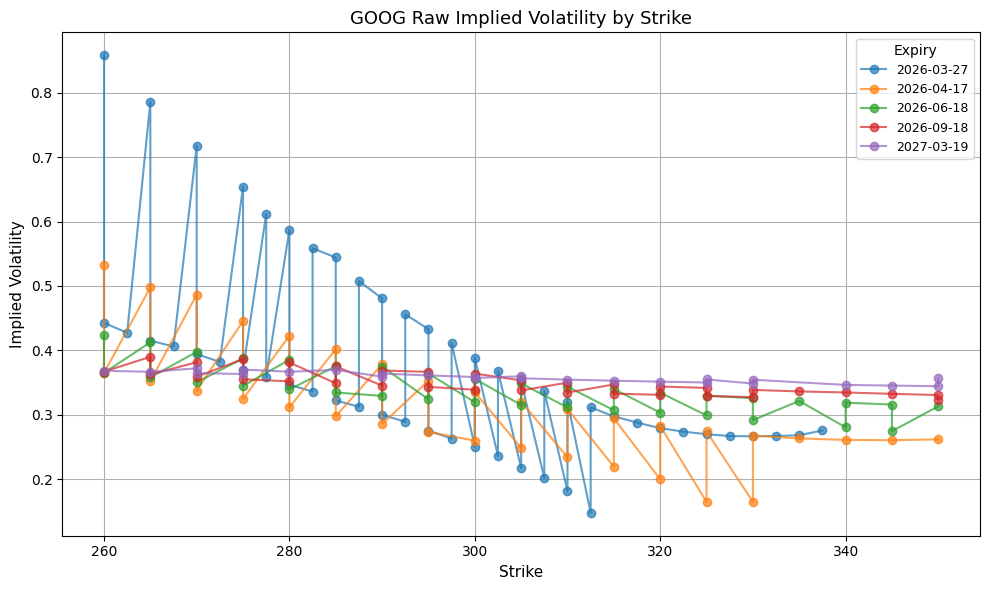

In [384]:
# Raw smile by strike -- expect a skew shape (higher IV for low strikes).
plt.figure()

for expiry, grp in options_iv.groupby("expiration"):
    grp_sorted = grp.sort_values("strike")
    plt.plot(
        grp_sorted["strike"], grp_sorted["iv_model"],
        marker="o", linestyle="-", alpha=0.7,
        label=str(expiry.date())
    )

plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title(f"{ticker} Raw Implied Volatility by Strike")
plt.legend(title="Expiry")
plt.tight_layout()
plt.show()

## 9. OTM-only representative smile

The smile is constructed using OTM options only:
- **OTM puts** for log-moneyness < 0 (strike below spot)
- **OTM calls** for log-moneyness > 0 (strike above spot)
- **ATM options** (|log-moneyness| <= 0.005) included from both sides

This is market-standard practice. ITM options are excluded because:
1. They are less liquid with wider bid-ask spreads
2. Their IVs can be distorted by early exercise premium
3. They carry no additional smile information beyond their OTM mirror

In [385]:
# Tag each row as OTM, ITM, or ATM.
# ATM band: |log-moneyness| <= 0.005 (within ~0.5% of spot).
atm_band = 0.005

def moneyness_flag(row):
    lm = row["log_moneyness"]
    ot = row["option_type"]
    if abs(lm) <= atm_band:
        return "atm"
    elif ot == "put" and lm < 0:
        return "otm"
    elif ot == "call" and lm > 0:
        return "otm"
    else:
        return "itm"

options_iv["moneyness_flag"] = options_iv.apply(moneyness_flag, axis=1)

print("Moneyness breakdown:")
print(options_iv["moneyness_flag"].value_counts())

Moneyness breakdown:
moneyness_flag
otm    99
itm    72
atm    10
Name: count, dtype: int64


In [386]:
# Keep OTM and ATM options only for smile construction.
smile_base = options_iv[options_iv["moneyness_flag"].isin(["otm", "atm"])].copy()

# One IV per (expiry, log-moneyness) point.
smile_logmny_df = (
    smile_base
    .groupby(["expiration", "log_moneyness"], as_index=False)["iv_model"]
    .mean()
    .sort_values(["expiration", "log_moneyness"])
)

print(f"Smile points: {len(smile_logmny_df)} across "
      f"{smile_logmny_df['expiration'].nunique()} expiries")
smile_logmny_df.head(10)

Smile points: 104 across 5 expiries


,expiration,log_moneyness,iv_model
0,2026-03-27,-0.157727,0.442833
1,2026-03-27,-0.148157,0.427354
2,2026-03-27,-0.138679,0.415064
3,2026-03-27,-0.129289,0.406133
4,2026-03-27,-0.119986,0.394100
5,2026-03-27,-0.110770,0.382247
6,2026-03-27,-0.101637,0.369979
7,2026-03-27,-0.092587,0.358739
8,2026-03-27,-0.083619,0.346702
9,2026-03-27,-0.074730,0.336148


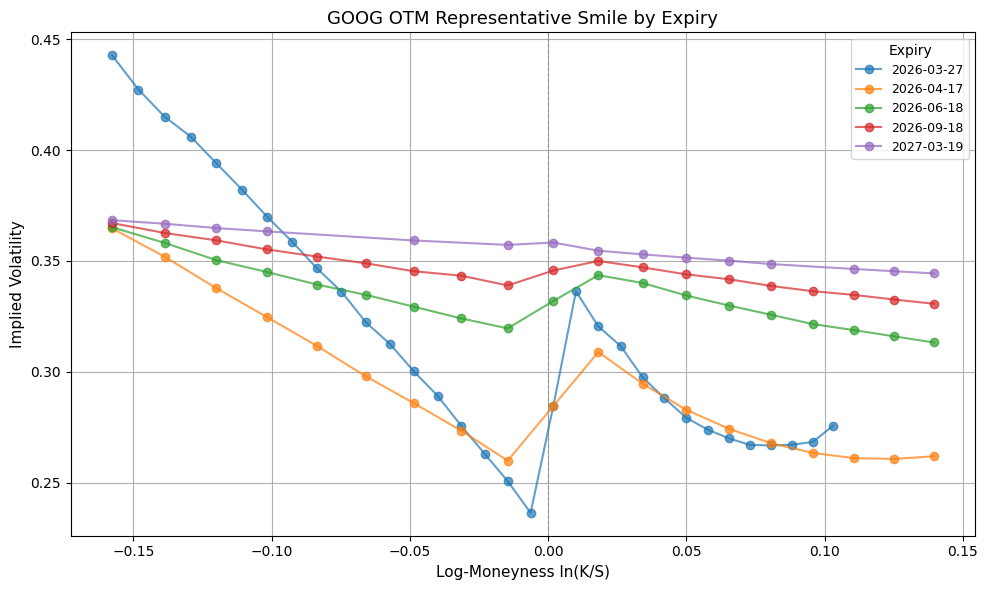

In [387]:
plt.figure()

for expiry, grp in smile_logmny_df.groupby("expiration"):
    plt.plot(
        grp["log_moneyness"], grp["iv_model"],
        marker="o", linestyle="-", alpha=0.7,
        label=str(expiry.date())
    )

plt.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.xlabel("Log-Moneyness ln(K/S)")
plt.ylabel("Implied Volatility")
plt.title(f"{ticker} OTM Representative Smile by Expiry")
plt.legend(title="Expiry")
plt.tight_layout()
plt.show()

## 10. SVI smile fitting

**SVI (Stochastic Volatility Inspired)** parametrises the total implied variance
`w(k) = IV(k)^2 * T` as a function of log-moneyness `k = ln(K/S)`:

```
w(k) = a + b * (rho * (k - m) + sqrt((k - m)^2 + sigma^2))
```

Parameters:
- `a` -- vertical shift (ATM variance level)
- `b` -- slope/curvature (controls overall spread of the smile)
- `rho` -- correlation/skew (negative = left-skewed, typical for equities)
- `m` -- horizontal shift (moves the minimum of the smile)
- `sigma` -- smoothness of the minimum (prevents a kink at the ATM)

**Why SVI instead of a spline:**
1. Arbitrage-free per slice by construction when parameter constraints hold
2. Principled parametric form with financial interpretation
3. Smooth extrapolation beyond the observed strike range
4. No magic smoothing parameter to tune

**Fitting in total variance space:** We fit `w = IV^2 * T` rather than IV
directly because total variance is the natural unit for option pricing --
it is additive across time and removes the maturity scaling effect.

In [388]:
def svi_total_variance(k, params):
    # SVI parametrisation: total implied variance as a function of log-moneyness.
    # params = (a, b, rho, m, sigma)
    a, b, rho, m, sigma = params
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))


def fit_svi(k_points, w_points, ttm):
    # Fit SVI parameters to a single expiry slice.
    #
    # k_points : log-moneyness array
    # w_points : total implied variance array (iv^2 * ttm)
    # ttm      : time to maturity in years (used to set sensible initial guess)
    #
    # Returns fitted params array (a, b, rho, m, sigma) or None if fit fails.

    def objective(params):
        w_model = svi_total_variance(k_points, params)
        # Guard against complex or negative values during optimisation
        if np.any(np.isnan(w_model)) or np.any(w_model < 0):
            return 1e10
        return np.sum((w_model - w_points)**2)

    # Estimate ATM total variance as starting point for a
    atm_idx  = np.argmin(np.abs(k_points))
    w_atm    = w_points[atm_idx]

    # Parameter bounds:
    # a in (0, max(w)): variance level must be positive
    # b >= 0: slope must be non-negative
    # rho in (-1, 1): correlation
    # m unconstrained: smile minimum can shift
    # sigma > 0: smoothness of the ATM region
    bounds = [
        (1e-6, float(np.max(w_points))),  # a
        (1e-6, 2.0),                       # b
        (-0.999, 0.999),                   # rho
        (-0.5, 0.5),                       # m
        (1e-4, 1.0),                       # sigma
    ]

    # Try multiple starting points to avoid local minima.
    # Equity smiles typically have negative rho (downward skew).
    starting_points = [
        [w_atm * 0.5, 0.10, -0.5, 0.0, 0.10],
        [w_atm * 0.5, 0.15, -0.7, 0.0, 0.15],
        [w_atm * 0.5, 0.05, -0.3, 0.0, 0.05],
        [w_atm * 0.8, 0.10, -0.5, 0.0, 0.20],
    ]

    best_result = None
    for p0 in starting_points:
        result = minimize(
            objective, p0, bounds=bounds,
            method="L-BFGS-B",
            options={"maxiter": 1000, "ftol": 1e-12}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    if best_result is not None and best_result.fun < 1e6:
        return best_result.x
    else:
        return None

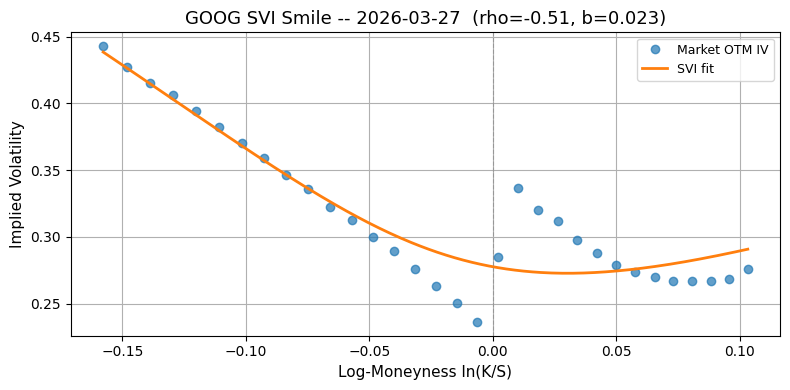

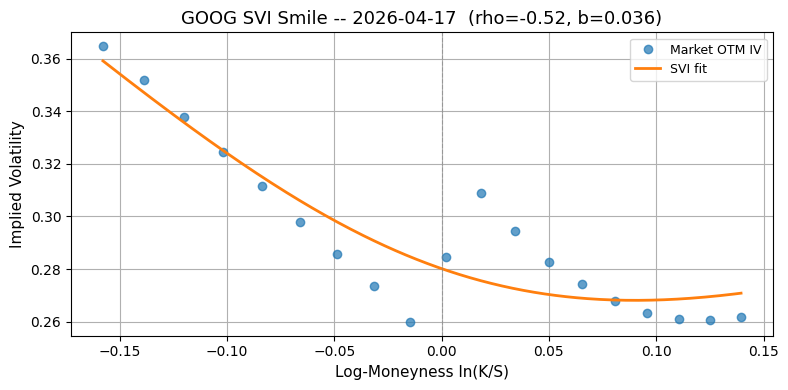

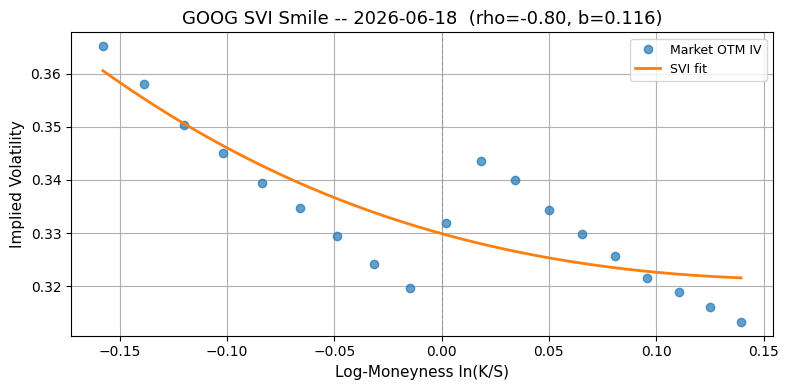

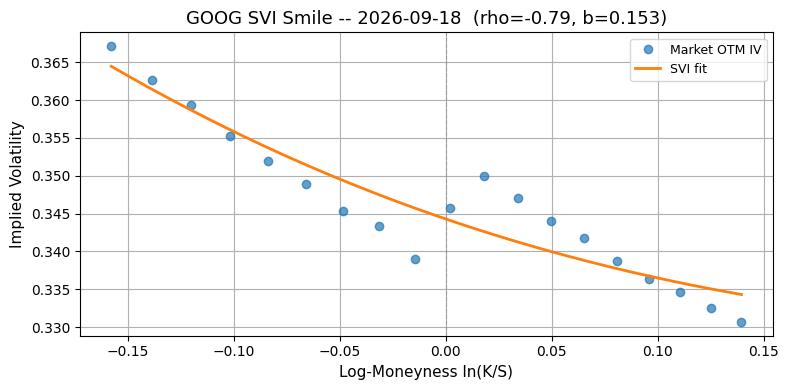

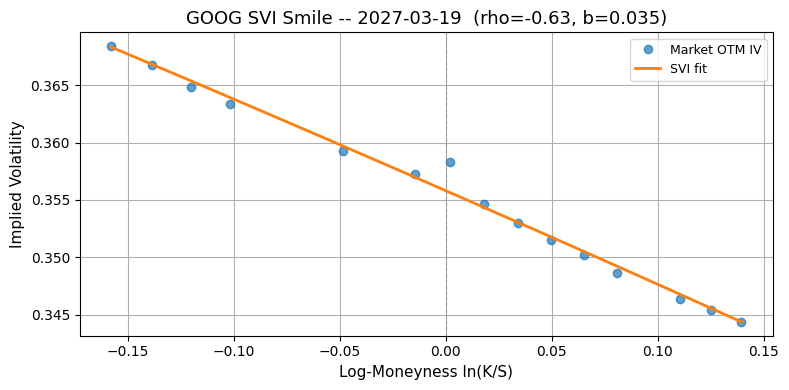

SVI fitted 5 expiry slices.
SVI smile grid points: 1500


In [389]:
# Fit SVI to each expiry slice and store results.

svi_smile_rows = []   # fitted smile points for plotting and surface building
svi_param_rows = []   # fitted parameters for inspection and saving

# Attach TTM to smile data for this section
expiry_ttm_map = (
    options_iv[["expiration", "ttm", "days_to_expiry"]]
    .drop_duplicates(subset=["expiration"])
    .sort_values("expiration")
    .reset_index(drop=True)
)

smile_with_ttm = smile_logmny_df.merge(expiry_ttm_map, on="expiration", how="left")

for expiry, grp in smile_with_ttm.groupby("expiration"):
    grp  = grp.sort_values("log_moneyness").copy()
    ttm  = float(grp["ttm"].iloc[0])

    if len(grp) < 5:
        print(f"Skipping {expiry.date()} -- too few points ({len(grp)}).")
        continue

    k = grp["log_moneyness"].values
    v = grp["iv_model"].values

    # Convert to total implied variance: w = IV^2 * T
    w = v**2 * ttm

    params = fit_svi(k, w, ttm)

    if params is None:
        print(f"WARNING: SVI fit failed for {expiry.date()}. Skipping.")
        continue

    a, b, rho, m, sigma = params

    # Evaluate fitted SVI curve on a dense grid
    k_grid = np.linspace(k.min(), k.max(), 300)
    w_grid = svi_total_variance(k_grid, params)

    # Clip to ensure non-negative total variance (numerical safety)
    w_grid = np.clip(w_grid, 1e-8, None)

    # Convert back to implied volatility: IV = sqrt(w / T)
    iv_grid = np.sqrt(w_grid / ttm)

    svi_smile_rows.append(pd.DataFrame({
        "expiration"   : expiry,
        "ttm"          : ttm,
        "log_moneyness": k_grid,
        "w_svi"        : w_grid,
        "iv_svi"       : iv_grid,
    }))

    svi_param_rows.append({
        "expiration": expiry,
        "ttm"       : ttm,
        "a"         : a,
        "b"         : b,
        "rho"       : rho,
        "m"         : m,
        "sigma"     : sigma,
        "fit_rmse"  : float(np.sqrt(np.mean((svi_total_variance(k, params) - w)**2))),
    })

    # Per-expiry plot: market points vs SVI fit
    plt.figure(figsize=(8, 4))
    plt.plot(k, v, "o", alpha=0.7, label="Market OTM IV")
    plt.plot(k_grid, iv_grid, "-", linewidth=2, label="SVI fit")
    plt.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    plt.xlabel("Log-Moneyness ln(K/S)")
    plt.ylabel("Implied Volatility")
    plt.title(f"{ticker} SVI Smile -- {expiry.date()}  "
              f"(rho={rho:.2f}, b={b:.3f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

svi_smile_df  = pd.concat(svi_smile_rows, ignore_index=True)
svi_params_df = pd.DataFrame(svi_param_rows)

print(f"SVI fitted {len(svi_params_df)} expiry slices.")
print(f"SVI smile grid points: {len(svi_smile_df)}")

In [390]:
# SVI parameter table -- gives a clear view of smile shape per expiry.
# rho: skew (negative = left-skewed equity smile)
# b: overall curvature/slope
# a: ATM total variance level
# fit_rmse: goodness of fit in total variance units
print("SVI parameters per expiry:")
svi_params_df.round(4)

SVI parameters per expiry:


/var/folders/_1/yj7p_4513mqg2rfc8lsxxx280000gp/T/ipykernel_61031/2306908562.py:7: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  svi_params_df.round(4)


,expiration,ttm,a,b,rho,m,sigma,fit_rmse
0,2026-03-27,0.0274,0.0000,0.0231,-0.5119,-0.0310,0.1027,0.0003
1,2026-04-17,0.0849,0.0000,0.0364,-0.5237,-0.0308,0.1967,0.0006
2,2026-06-18,0.2548,0.0021,0.1161,-0.7970,-0.2829,0.3447,0.0012
3,2026-09-18,0.5068,0.0000,0.1525,-0.7946,-0.4181,0.5938,0.0012
4,2027-03-19,1.0055,0.0984,0.0354,-0.6337,0.5000,0.0001,0.0006


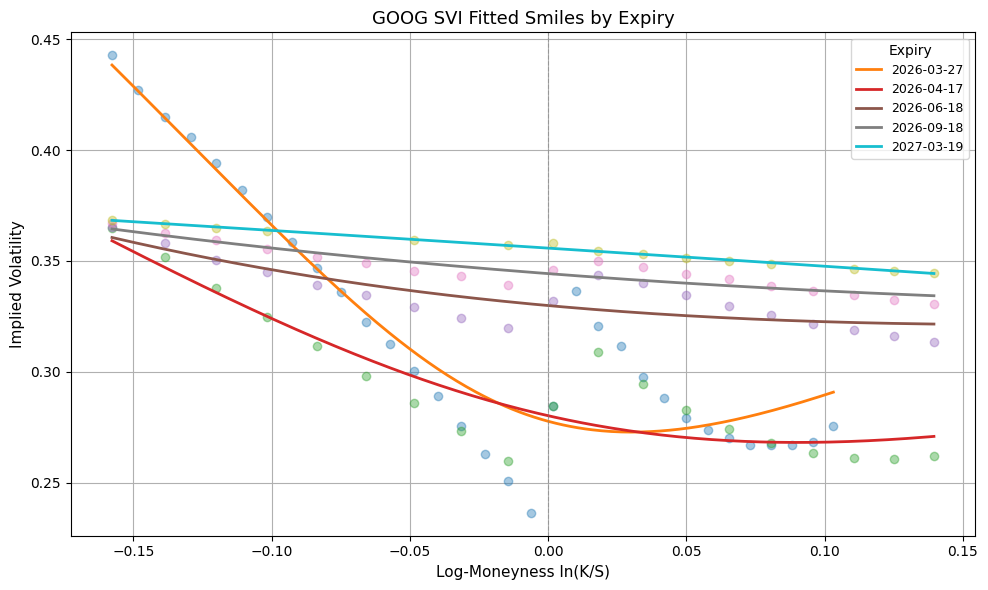

In [391]:
# Combined overlay: market points vs SVI fit across all expiries.
plt.figure()

for expiry, grp in smile_with_ttm.groupby("expiration"):
    raw_iv = grp.sort_values("log_moneyness")
    svi_grp = svi_smile_df[svi_smile_df["expiration"] == expiry]

    plt.plot(raw_iv["log_moneyness"], raw_iv["iv_model"], "o", alpha=0.4)
    plt.plot(
        svi_grp["log_moneyness"], svi_grp["iv_svi"],
        "-", linewidth=2, label=str(pd.to_datetime(expiry).date())
    )

plt.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
plt.xlabel("Log-Moneyness ln(K/S)")
plt.ylabel("Implied Volatility")
plt.title(f"{ticker} SVI Fitted Smiles by Expiry")
plt.legend(title="Expiry")
plt.tight_layout()
plt.savefig("outputs/plots/svi_smiles_by_expiry.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Realized volatility benchmark

Computes rolling realized volatility from the historical spot price series.
Annualised using sqrt(252) (trading-days convention).

In [392]:
spot_hist = pd.read_csv("data/raw/spot_history.csv")

# yfinance timestamps are tz-aware; strip timezone for clean arithmetic.
spot_hist["date"] = pd.to_datetime(spot_hist["date"], utc=True).dt.tz_convert(None)
spot_hist = spot_hist.sort_values("date").copy()

# Daily log returns
spot_hist["log_return"] = np.log(spot_hist["close"] / spot_hist["close"].shift(1))
spot_hist = spot_hist.dropna(subset=["log_return"]).copy()

# Rolling annualised realized volatility at four horizons
spot_hist["rv_21d"]  = spot_hist["log_return"].rolling(21).std()  * np.sqrt(252)
spot_hist["rv_63d"]  = spot_hist["log_return"].rolling(63).std()  * np.sqrt(252)
spot_hist["rv_126d"] = spot_hist["log_return"].rolling(126).std() * np.sqrt(252)
spot_hist["rv_252d"] = spot_hist["log_return"].rolling(252).std() * np.sqrt(252)

spot_hist[["date", "close", "rv_21d", "rv_63d", "rv_126d", "rv_252d"]].tail()

,date,close,rv_21d,rv_63d,rv_126d,rv_252d
547,2026-03-10 04:00:00,306.929993,0.231344,0.222240,0.259420,0.303590
548,2026-03-11 04:00:00,308.420013,0.231652,0.217415,0.257508,0.299679
549,2026-03-12 04:00:00,303.209991,0.230903,0.218835,0.258864,0.300012
550,2026-03-13 04:00:00,301.459991,0.218686,0.217924,0.259049,0.299711
551,2026-03-16 04:00:00,304.420013,0.221339,0.214300,0.259294,0.298491


## 12. Near-ATM IV vs realized vol

Compares near-ATM implied volatility against the realized vol benchmark
at each expiry horizon. A positive difference (IV > RV) is the typical
volatility risk premium.

In [393]:
# Near-ATM: |log-moneyness| <= 0.03 (within ~3% of spot)
atm_iv_df = options_iv[np.abs(options_iv["log_moneyness"]) <= 0.03].copy()

expiry_iv_summary = (
    atm_iv_df
    .groupby("expiration", as_index=False)
    .agg(
        avg_atm_iv    =("iv_model",       "mean"),
        days_to_expiry=("days_to_expiry", "first"),
    )
)

latest_rv = spot_hist.iloc[-1]

def map_realized_vol(days):
    # Map expiry horizon to the closest realized vol window.
    if days <= 30:
        return latest_rv["rv_21d"]
    elif days <= 90:
        return latest_rv["rv_63d"]
    elif days <= 180:
        return latest_rv["rv_126d"]
    else:
        return latest_rv["rv_252d"]

expiry_iv_summary["realized_vol_benchmark"] = (
    expiry_iv_summary["days_to_expiry"].apply(map_realized_vol)
)
expiry_iv_summary["iv_minus_rv"] = (
    expiry_iv_summary["avg_atm_iv"] - expiry_iv_summary["realized_vol_benchmark"]
)

expiry_iv_summary

,expiration,avg_atm_iv,days_to_expiry,realized_vol_benchmark,iv_minus_rv
0,2026-03-27,0.284847,10,0.221339,0.063508
1,2026-04-17,0.284593,31,0.214300,0.070293
2,2026-06-18,0.332393,93,0.259294,0.073100
3,2026-09-18,0.346521,185,0.298491,0.048029
4,2027-03-19,0.357435,367,0.298491,0.058944


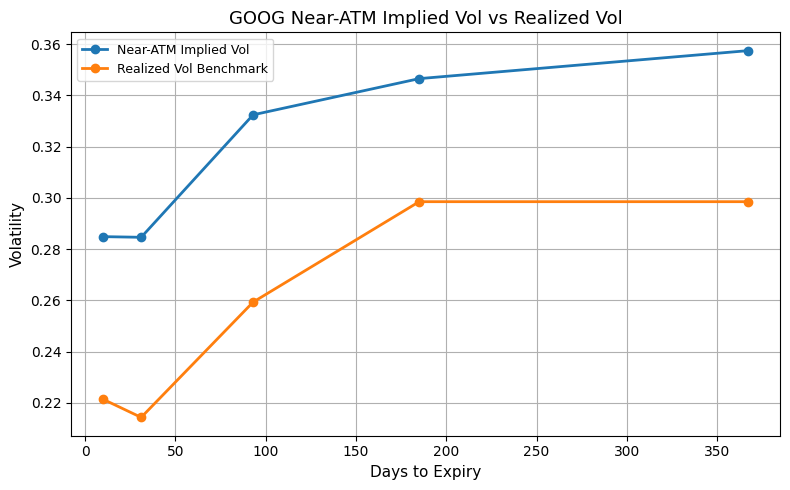

In [394]:
plt.figure(figsize=(8, 5))
plt.plot(expiry_iv_summary["days_to_expiry"], expiry_iv_summary["avg_atm_iv"],
         marker="o", linewidth=2, label="Near-ATM Implied Vol")
plt.plot(expiry_iv_summary["days_to_expiry"], expiry_iv_summary["realized_vol_benchmark"],
         marker="o", linewidth=2, label="Realized Vol Benchmark")
plt.xlabel("Days to Expiry")
plt.ylabel("Volatility")
plt.title(f"{ticker} Near-ATM Implied Vol vs Realized Vol")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/plots/atm_iv_vs_realized_vol.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Build volatility surface in total variance space

The surface is built by interpolating **total implied variance** `w = IV^2 * T`
rather than IV directly. This is the correct approach because:

1. **Calendar no-arbitrage** requires that total variance is non-decreasing in T
   at any fixed moneyness. Interpolating w directly preserves this property;
   interpolating IV does not.
2. **Consistent scaling** -- w removes the sqrt(T) scaling effect that makes
   short-dated and long-dated IVs hard to compare numerically.
3. **Alignment with SVI** -- the SVI fit was performed in w-space, so the surface
   should be built and queried in the same space for consistency.

The workflow:
1. Build the surface grid from SVI-fitted total variance points
2. Fit interpolators in w-space
3. At query time, convert back to IV via `IV = sqrt(w / T)`

In [395]:
# Build the surface point cloud from SVI-fitted smiles.
# days_to_expiry is not in svi_smile_df directly -- merge it from expiry_ttm_map.
vol_surface_points = svi_smile_df.merge(
    expiry_ttm_map[["expiration", "days_to_expiry"]],
    on="expiration",
    how="left"
)[["expiration", "ttm", "days_to_expiry", "log_moneyness", "w_svi", "iv_svi"]].copy()

# Rename iv_svi to iv_smooth for compatibility with downstream cells
vol_surface_points = vol_surface_points.rename(columns={"iv_svi": "iv_smooth"})

surface_summary = pd.Series({
    "num_surface_points": len(vol_surface_points),
    "num_expiries"      : vol_surface_points["expiration"].nunique(),
    "log_moneyness_min" : float(vol_surface_points["log_moneyness"].min()),
    "log_moneyness_max" : float(vol_surface_points["log_moneyness"].max()),
    "ttm_min"           : float(vol_surface_points["ttm"].min()),
    "ttm_max"           : float(vol_surface_points["ttm"].max()),
    "w_min"             : float(vol_surface_points["w_svi"].min()),
    "w_max"             : float(vol_surface_points["w_svi"].max()),
    "iv_smooth_min"     : float(vol_surface_points["iv_smooth"].min()),
    "iv_smooth_max"     : float(vol_surface_points["iv_smooth"].max()),
})

surface_summary

num_surface_points    1500.000000
num_expiries             5.000000
log_moneyness_min       -0.157727
log_moneyness_max        0.139525
ttm_min                  0.027397
ttm_max                  1.005479
w_min                    0.002039
w_max                    0.136403
iv_smooth_min            0.268134
iv_smooth_max            0.438408
dtype: float64

In [396]:
# Build 2D interpolators on (log_moneyness, ttm) -> total implied variance w.
# Interpolating in w-space rather than IV-space preserves calendar no-arbitrage.

surface_xy = vol_surface_points[["log_moneyness", "ttm"]].values
surface_w  = vol_surface_points["w_svi"].values

w_surface_linear  = LinearNDInterpolator(surface_xy, surface_w)
w_surface_nearest = NearestNDInterpolator(surface_xy, surface_w)

print("Total variance surface interpolators created.")

# Persist to disk so NB04 can load the surface without rerunning NB03.
# NB04 will query w, then convert back to IV via sqrt(w / ttm).
joblib.dump(w_surface_linear,  "data/processed/iv_surface_linear.pkl")
joblib.dump(w_surface_nearest, "data/processed/iv_surface_nearest.pkl")
print("Interpolators saved to data/processed/")

Total variance surface interpolators created.
Interpolators saved to data/processed/


## 14. No-arbitrage term structure check

Total implied variance `w = IV^2 * T` must be non-decreasing in T at any
fixed log-moneyness for the surface to be free of calendar spread arbitrage.
We check this at ATM (log-moneyness = 0) as a representative test.

Because we built the surface in w-space and the SVI fit was done per slice,
this check confirms whether the fitted ATM variances respect the term structure.

In [397]:
# Sample total variance at log-moneyness = 0 across all expiry TTMs.
atm_ttms = expiry_ttm_map["ttm"].sort_values().values
atm_ws   = []
for t in atm_ttms:
    w_val = float(w_surface_linear(0.0, t))
    if np.isnan(w_val):
        w_val = float(w_surface_nearest(0.0, t))
    atm_ws.append(w_val)
atm_ws = np.array(atm_ws)

# Convert total variance back to ATM IV for display
atm_ivs = np.sqrt(atm_ws / atm_ttms)

atm_term_structure = pd.DataFrame({
    "ttm"      : atm_ttms,
    "atm_w"    : atm_ws,
    "atm_iv"   : atm_ivs,
})

# Violation: total variance decreases between adjacent expiries.
# Tolerance of 1e-4 allows for minor numerical noise.
violations = (np.diff(atm_ws) < -1e-4).sum()

if violations == 0:
    print("Term structure check PASSED -- ATM total variance is non-decreasing in TTM.")
else:
    print(f"WARNING: {violations} calendar arbitrage violation(s) detected in w-space.")
    print("This means the SVI ATM levels are not monotone across expiries.")
    print("Review the svi_params_df table -- check the 'a' parameter across expiries.")

atm_term_structure

Term structure check PASSED -- ATM total variance is non-decreasing in TTM.


,ttm,atm_w,atm_iv
0,0.027397,0.002112,0.277679
1,0.084932,0.006668,0.280190
2,0.254795,0.027728,0.329887
3,0.506849,0.060082,0.344297
4,1.005479,0.127291,0.355804


## 15. Engine IV for pricing models

Queries the volatility surface for each option row to produce `iv_engine` --
the smoothed, surface-consistent IV that NB04 uses as the volatility input
to all pricing models.

Query process:
1. Look up total variance `w` at (log_moneyness, TTM) from the surface
2. Convert to IV via `IV = sqrt(w / TTM)`

This ensures the engine IV is consistent with the SVI fit and the
total variance interpolation.

In [398]:
def get_engine_iv(log_moneyness, ttm):
    # Query the total variance surface and convert back to IV.
    # Uses linear interpolation with nearest-neighbour fallback.
    if ttm <= 0:
        return np.nan

    w_val = w_surface_linear(log_moneyness, ttm)
    if np.ndim(w_val) > 0:
        w_val = w_val.item()

    if pd.isna(w_val):
        w_val = w_surface_nearest(log_moneyness, ttm)
        if np.ndim(w_val) > 0:
            w_val = w_val.item()

    # Guard: total variance must be non-negative
    w_val = max(float(w_val), 1e-8)

    return float(np.sqrt(w_val / ttm))


options_iv["iv_engine"] = options_iv.apply(
    lambda row: get_engine_iv(row["log_moneyness"], row["ttm"]),
    axis=1
)

options_iv[[
    "expiration", "option_type", "strike", "ttm",
    "log_moneyness", "iv_model", "iv_engine"
]].head(10)

,expiration,option_type,strike,ttm,log_moneyness,iv_model,iv_engine
0,2026-03-27,call,260.0,0.027397,-0.157727,0.858201,0.438408
1,2026-03-27,call,265.0,0.027397,-0.138679,0.785758,0.414633
2,2026-03-27,call,270.0,0.027397,-0.119986,0.717533,0.391120
3,2026-03-27,call,275.0,0.027397,-0.101637,0.654371,0.368219
4,2026-03-27,call,277.5,0.027397,-0.092587,0.611943,0.357149
5,2026-03-27,call,280.0,0.027397,-0.083619,0.586850,0.346432
6,2026-03-27,call,282.5,0.027397,-0.074730,0.558498,0.336158
7,2026-03-27,call,285.0,0.027397,-0.065919,0.544252,0.326418
8,2026-03-27,call,287.5,0.027397,-0.057186,0.507600,0.317309
9,2026-03-27,call,290.0,0.027397,-0.048527,0.480777,0.308922


In [399]:
iv_engine_summary = pd.Series({
    "rows_total"               : len(options_iv),
    "rows_with_iv_engine"      : int(options_iv["iv_engine"].notna().sum()),
    "iv_engine_min"            : float(options_iv["iv_engine"].min(skipna=True)),
    "iv_engine_max"            : float(options_iv["iv_engine"].max(skipna=True)),
    "iv_engine_mean"           : float(options_iv["iv_engine"].mean(skipna=True)),
    "mean_abs_diff_engine_vs_raw": float(
        (options_iv["iv_engine"] - options_iv["iv_model"]).abs().mean()
    ),
})

iv_engine_summary

rows_total                     181.000000
rows_with_iv_engine            181.000000
iv_engine_min                    0.268172
iv_engine_max                    0.438408
iv_engine_mean                   0.328524
mean_abs_diff_engine_vs_raw      0.038200
dtype: float64

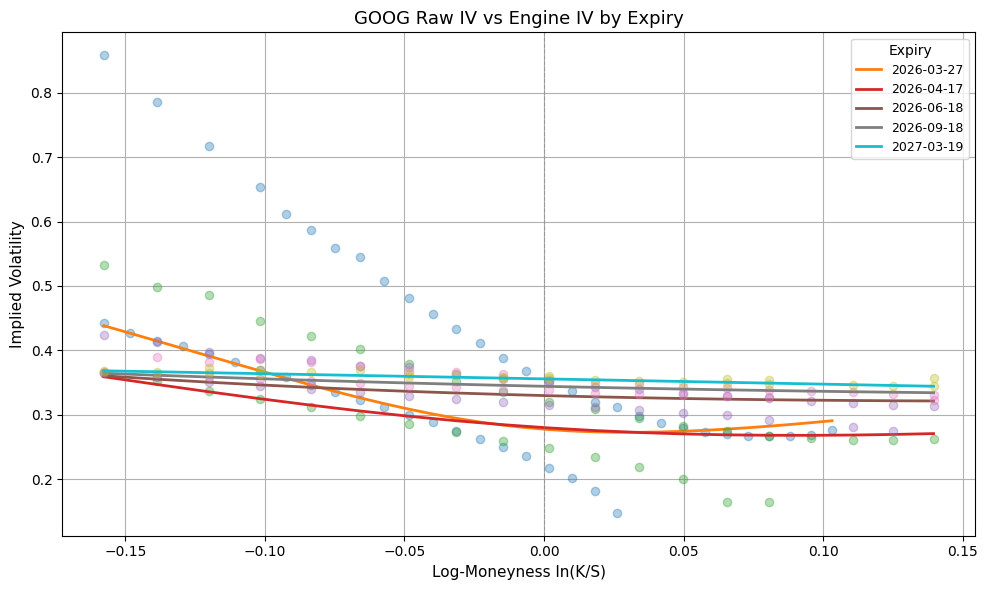

In [400]:
# Overlay: raw IV (dots) vs engine IV (lines) per expiry.
plt.figure()

for expiry, grp in options_iv.groupby("expiration"):
    grp = grp.sort_values("log_moneyness")
    plt.plot(grp["log_moneyness"], grp["iv_model"],  "o", alpha=0.35)
    plt.plot(grp["log_moneyness"], grp["iv_engine"], "-", linewidth=2,
             label=str(expiry.date()))

plt.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
plt.xlabel("Log-Moneyness ln(K/S)")
plt.ylabel("Implied Volatility")
plt.title(f"{ticker} Raw IV vs Engine IV by Expiry")
plt.legend(title="Expiry")
plt.tight_layout()
plt.savefig("outputs/plots/raw_vs_engine_iv.png", dpi=300, bbox_inches="tight")
plt.show()

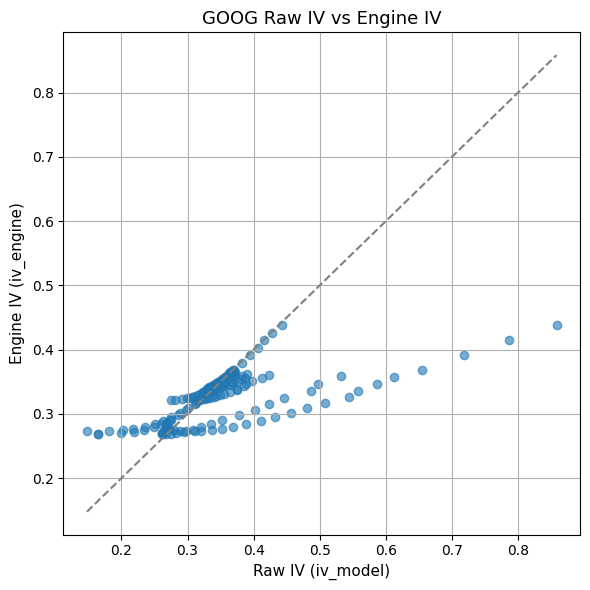

In [401]:
# Scatter: raw IV vs engine IV -- should cluster near the 45-degree line.
plt.figure(figsize=(6, 6))
plt.scatter(options_iv["iv_model"], options_iv["iv_engine"], alpha=0.6)

xy_min = min(options_iv["iv_model"].min(), options_iv["iv_engine"].min())
xy_max = max(options_iv["iv_model"].max(), options_iv["iv_engine"].max())
plt.plot([xy_min, xy_max], [xy_min, xy_max], "--", linewidth=1.5, color="gray")

plt.xlabel("Raw IV (iv_model)")
plt.ylabel("Engine IV (iv_engine)")
plt.title(f"{ticker} Raw IV vs Engine IV")
plt.tight_layout()
plt.savefig("outputs/plots/iv_model_vs_iv_engine_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Surface visualisation

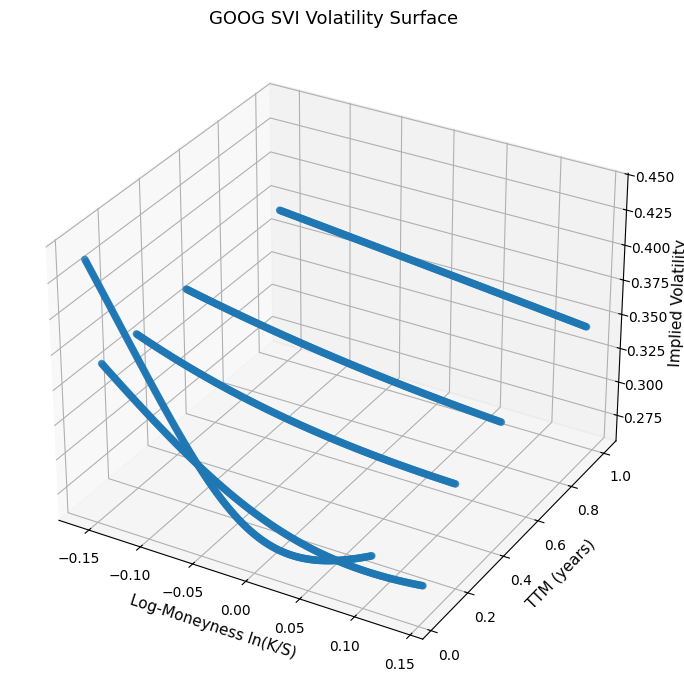

In [402]:
# Matplotlib 3D scatter of the SVI surface points.
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")

ax.scatter(
    vol_surface_points["log_moneyness"],
    vol_surface_points["ttm"],
    vol_surface_points["iv_smooth"],
    alpha=0.7
)

ax.set_xlabel("Log-Moneyness ln(K/S)")
ax.set_ylabel("TTM (years)")
ax.set_zlabel("Implied Volatility")
ax.set_title(f"{ticker} SVI Volatility Surface")
plt.tight_layout()
plt.savefig("outputs/plots/iv_surface_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [403]:
# Interpolate onto a regular grid for the interactive Plotly surface.
x_vals = np.linspace(vol_surface_points["log_moneyness"].min(),
                     vol_surface_points["log_moneyness"].max(), 80)
y_vals = np.linspace(vol_surface_points["ttm"].min(),
                     vol_surface_points["ttm"].max(), 80)
X, Y   = np.meshgrid(x_vals, y_vals)

# Interpolate in total variance space then convert to IV for display
pts = vol_surface_points[["log_moneyness", "ttm"]].values
ws  = vol_surface_points["w_svi"].values

W         = griddata(pts, ws, (X, Y), method="linear")
W_nearest = griddata(pts, ws, (X, Y), method="nearest")
W         = np.where(np.isnan(W), W_nearest, W)
W         = np.clip(W, 1e-8, None)

# Convert total variance grid back to IV for the z-axis
Z = np.sqrt(W / Y)

fig = go.Figure()

fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    colorscale="Viridis", opacity=0.88, showscale=True, name="IV Surface"
))
fig.add_trace(go.Scatter3d(
    x=vol_surface_points["log_moneyness"],
    y=vol_surface_points["ttm"],
    z=vol_surface_points["iv_smooth"],
    mode="markers",
    marker=dict(size=3, color="red"),
    name="SVI Points"
))

fig.update_layout(
    title=f"{ticker} Implied Volatility Surface (SVI + Total Variance Interpolation)",
    width=950, height=700,
    scene=dict(
        xaxis_title="Log-Moneyness ln(K/S)",
        yaxis_title="TTM (years)",
        zaxis_title="Implied Volatility",
        yaxis=dict(
            tickvals=[7/365, 30/365, 90/365, 180/365, 365/365],
            ticktext=["7d", "30d", "90d", "180d", "365d"]
        )
    )
)

fig.write_html("outputs/plots/iv_surface.html")
print("Interactive surface saved to outputs/plots/iv_surface.html")
fig.show()

Interactive surface saved to outputs/plots/iv_surface.html


## 17. Save all outputs

In [404]:
# Processed data files
options_iv.to_csv("data/processed/options_with_iv.csv",                    index=False)
options_iv.to_csv("data/processed/options_with_iv_engine.csv",             index=False)
smile_logmny_df.to_csv("data/processed/smile_logmoneyness.csv",            index=False)
svi_smile_df.to_csv("data/processed/smile_svi.csv",                        index=False)
svi_params_df.to_csv("data/processed/svi_params.csv",                      index=False)
vol_surface_points.to_csv("data/processed/vol_surface_points.csv",         index=False)
expiry_iv_summary.to_csv("data/processed/iv_vs_realized_summary.csv",      index=False)

print("Saved data/processed/ files.")

# IV summary tables
iv_summary.reset_index().rename(
    columns={"index": "metric", 0: "value"}
).to_csv("outputs/tables/notebook3_iv_summary.csv", index=False)

iv_engine_summary.reset_index().rename(
    columns={"index": "metric", 0: "value"}
).to_csv("outputs/tables/notebook3_iv_engine_summary.csv", index=False)

svi_params_df.to_csv("outputs/tables/notebook3_svi_params.csv", index=False)

# Surface validation summary
surface_validation_summary = pd.Series({
    "surface_points"             : len(vol_surface_points),
    "unique_expiries"            : vol_surface_points["expiration"].nunique(),
    "log_moneyness_min"          : float(vol_surface_points["log_moneyness"].min()),
    "log_moneyness_max"          : float(vol_surface_points["log_moneyness"].max()),
    "ttm_min"                    : float(vol_surface_points["ttm"].min()),
    "ttm_max"                    : float(vol_surface_points["ttm"].max()),
    "iv_smooth_min"              : float(vol_surface_points["iv_smooth"].min()),
    "iv_smooth_max"              : float(vol_surface_points["iv_smooth"].max()),
    "engine_iv_rows"             : int(options_iv["iv_engine"].notna().sum()),
    "engine_iv_missing_rows"     : int(options_iv["iv_engine"].isna().sum()),
    "mean_abs_diff_engine_vs_raw": float(
        (options_iv["iv_engine"] - options_iv["iv_model"]).abs().mean()
    ),
    "max_abs_diff_engine_vs_raw" : float(
        (options_iv["iv_engine"] - options_iv["iv_model"]).abs().max()
    ),
})

surface_validation_summary.reset_index().rename(
    columns={"index": "metric", 0: "value"}
).to_csv("outputs/tables/notebook3_surface_validation_summary.csv", index=False)

# Surface validation by expiry
mad_by_expiry = (
    options_iv
    .assign(abs_diff=lambda df: (df["iv_engine"] - df["iv_model"]).abs())
    .groupby("expiration", as_index=False)["abs_diff"]
    .mean()
    .rename(columns={"abs_diff": "mean_abs_diff"})
)

surface_validation_by_expiry = (
    options_iv
    .groupby("expiration", as_index=False)
    .agg(
        rows          =("iv_engine", "size"),
        iv_model_mean =("iv_model",  "mean"),
        iv_engine_mean=("iv_engine", "mean"),
    )
    .merge(mad_by_expiry, on="expiration", how="left")
)

surface_validation_by_expiry.to_csv(
    "outputs/tables/notebook3_surface_validation_by_expiry.csv", index=False
)

print("Saved outputs/tables/ files.")

Saved data/processed/ files.
Saved outputs/tables/ files.


## 18. Final summary

In [405]:
final_summary = pd.Series({
    "ticker"              : ticker,
    "rows_with_iv"        : len(options_iv),
    "num_expiries"        : options_iv["expiration"].nunique(),
    "num_calls"           : int((options_iv["option_type"] == "call").sum()),
    "num_puts"            : int((options_iv["option_type"] == "put").sum()),
    "iv_min"              : float(options_iv["iv_model"].min()),
    "iv_max"              : float(options_iv["iv_model"].max()),
    "iv_engine_min"       : float(options_iv["iv_engine"].min()),
    "iv_engine_max"       : float(options_iv["iv_engine"].max()),
    "strike_min"          : float(options_iv["strike"].min()),
    "strike_max"          : float(options_iv["strike"].max()),
    "surface_points"      : len(vol_surface_points),
    "svi_expiries_fitted" : len(svi_params_df),
    "svi_avg_rmse"        : float(svi_params_df["fit_rmse"].mean()),
})

final_summary

ticker                     GOOG
rows_with_iv                181
num_expiries                  5
num_calls                   101
num_puts                     80
iv_min                  0.14787
iv_max                 0.858201
iv_engine_min          0.268172
iv_engine_max          0.438408
strike_min                260.0
strike_max                350.0
surface_points             1500
svi_expiries_fitted           5
svi_avg_rmse           0.000797
dtype: object

In [406]:
surface_validation_by_expiry

,expiration,rows,iv_model_mean,iv_engine_mean,mean_abs_diff
0,2026-03-27,51,0.378734,0.319876,0.082070
1,2026-04-17,34,0.314382,0.296195,0.047609
2,2026-06-18,36,0.339401,0.334472,0.020222
3,2026-09-18,34,0.350388,0.346400,0.009270
4,2027-03-19,26,0.358455,0.356152,0.002567
